In [256]:
import pandas as pd
df = pd.read_csv('data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [257]:
import pandas as pd
import re

df = pd.read_csv('data/train.csv')

# ── Helpers ────────────────────────────────────────────────────────────────
def section(title):
    print(f"\n{'═'*50}")
    print(f"  {title}")
    print(f"{'═'*50}")

def nulls(col):
    n = df[col].isna().sum()
    pct = n / len(df) * 100
    return f"nulls: {n} ({pct:.1f}%)"

# ── PassengerId ────────────────────────────────────────────────────────────
section("PassengerId")
print(f"Range: {df['PassengerId'].min()} – {df['PassengerId'].max()}  (just an index, no signal)")

# ── Survived ───────────────────────────────────────────────────────────────
section("Survived  [target]")
print(df['Survived'].value_counts().rename({0: 'Died', 1: 'Survived'}))
print(f"Survival rate: {df['Survived'].mean():.1%}")

# ── Pclass ─────────────────────────────────────────────────────────────────
section("Pclass  [ordinal: 1=first, 2=second, 3=third]")
print(df.groupby('Pclass')['Survived'].agg(['count', 'mean']).rename(columns={'mean': 'survival_rate'}))

# ── Name → Title ───────────────────────────────────────────────────────────
section("Name  →  extracted titles")
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
print(df['Title'].value_counts().to_string())

# ── Sex ────────────────────────────────────────────────────────────────────
section("Sex")
print(df.groupby('Sex')['Survived'].agg(['count', 'mean']).rename(columns={'mean': 'survival_rate'}))

# ── Age ────────────────────────────────────────────────────────────────────
section(f"Age  [numerical]  —  {nulls('Age')}")
print(f"Range : {df['Age'].min():.0f} – {df['Age'].max():.0f}")
print(f"Mean  : {df['Age'].mean():.1f}   Median: {df['Age'].median():.1f}")
print(f"\nTop 5 most common ages:")
print(df['Age'].value_counts().head(5))
print(f"\nDistribution by decade:")
print(pd.cut(df['Age'], bins=[0,10,20,30,40,50,60,70,80], right=False)
        .value_counts().sort_index())

# ── SibSp ──────────────────────────────────────────────────────────────────
section("SibSp  [# siblings + spouses aboard]")
print(df.groupby('SibSp')['Survived'].agg(['count', 'mean']).rename(columns={'mean': 'survival_rate'}))

# ── Parch ──────────────────────────────────────────────────────────────────
section("Parch  [# parents + children aboard]")
print(df.groupby('Parch')['Survived'].agg(['count', 'mean']).rename(columns={'mean': 'survival_rate'}))

# ── Fare ───────────────────────────────────────────────────────────────────
section(f"Fare  [numerical]  —  {nulls('Fare')}")
print(f"Range  : £{df['Fare'].min():.2f} – £{df['Fare'].max():.2f}")
print(f"Mean   : £{df['Fare'].mean():.2f}   Median: £{df['Fare'].median():.2f}")
print(f"\nPercentiles:")
print(df['Fare'].quantile([0.25, 0.50, 0.75, 0.90, 0.99]).to_string())

# ── Cabin ──────────────────────────────────────────────────────────────────
section(f"Cabin  —  {nulls('Cabin')}")
print(f"\nHas cabin: {df['Cabin'].notna().sum()} | No cabin: {df['Cabin'].isna().sum()}")
print(f"Survival rate with cabin   : {df[df['Cabin'].notna()]['Survived'].mean():.1%}")
print(f"Survival rate without cabin: {df[df['Cabin'].isna()]['Survived'].mean():.1%}")

# ── Embarked ───────────────────────────────────────────────────────────────
section(f"Embarked  [C=Cherbourg, Q=Queenstown, S=Southampton]  —  {nulls('Embarked')}")
print(df.groupby('Embarked')['Survived'].agg(['count', 'mean']).rename(columns={'mean': 'survival_rate'}))

# ── Ticket ─────────────────────────────────────────────────────────────────
section("Ticket  [high cardinality — raw value mostly noise]")
print(f"Unique tickets : {df['Ticket'].nunique()} out of {len(df)} rows")
print(f"Top 5 repeated tickets (shared tickets = travel groups):")
print(df['Ticket'].value_counts().head(5))


══════════════════════════════════════════════════
  PassengerId
══════════════════════════════════════════════════
Range: 1 – 891  (just an index, no signal)

══════════════════════════════════════════════════
  Survived  [target]
══════════════════════════════════════════════════
Survived
Died        549
Survived    342
Name: count, dtype: int64
Survival rate: 38.4%

══════════════════════════════════════════════════
  Pclass  [ordinal: 1=first, 2=second, 3=third]
══════════════════════════════════════════════════
        count  survival_rate
Pclass                      
1         216       0.629630
2         184       0.472826
3         491       0.242363

══════════════════════════════════════════════════
  Name  →  extracted titles
══════════════════════════════════════════════════
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don            

In [258]:

# Survival rate by present vs null for each column
print(f"{'Column':<15} {'Present':>10} {'Null':>10} {'Δ':>8}")
print("─" * 45)
for col in df.columns:
    if col == 'Survived':
        continue
    has = df[col].notna()
    n_present = has.sum()
    n_null = (~has).sum()
    if n_null == 0:
        continue
    rate_present = df.loc[has, 'Survived'].mean()
    rate_null = df.loc[~has, 'Survived'].mean()
    delta = rate_present - rate_null
    print(f"{col:<15} {rate_present:>9.1%} {rate_null:>9.1%} {delta:>+7.1%}")
    print(f"{'':15} (n={n_present:<4})    (n={n_null:<4})")


Column             Present       Null        Δ
─────────────────────────────────────────────
Age                 40.6%     29.4%  +11.2%
                (n=714 )    (n=177 )
Cabin               66.7%     30.0%  +36.7%
                (n=204 )    (n=687 )
Embarked            38.2%    100.0%  -61.8%
                (n=889 )    (n=2   )


We will investigate each for NaN, and make recommendations for handling NaN:
1. Cabin
2. Embarked
3. Deck

### Cramers V
Want to find correlations between categories missingness (categorical dtype) and other category values

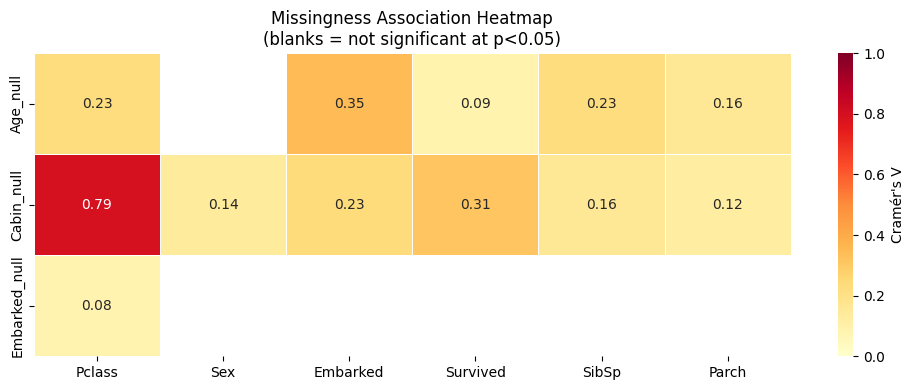

In [259]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    return v, p

# Create null flags
null_cols = ['Age', 'Cabin', 'Embarked']
for col in null_cols:
    df[f'{col}_null'] = df[col].isna().astype(int)

# Columns to test against
categoricals = ['Pclass', 'Sex', 'Embarked', 'Survived', 'SibSp', 'Parch']
null_flags = ['Age_null', 'Cabin_null', 'Embarked_null']

# Build matrix
v_matrix = pd.DataFrame(index=null_flags, columns=categoricals)
p_matrix = pd.DataFrame(index=null_flags, columns=categoricals)

for row in null_flags:
    for col in categoricals:
        v, p = cramers_v(df[row], df[col])
        v_matrix.loc[row, col] = v
        p_matrix.loc[row, col] = p

v_matrix = v_matrix.astype(float)
p_matrix = p_matrix.astype(float)

# Mask insignificant results
masked = v_matrix.where(p_matrix < 0.05)

# Plot
plt.figure(figsize=(10, 4))
sns.heatmap(masked, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': "Cramér's V"})
plt.title("Missingness Association Heatmap\n(blanks = not significant at p<0.05)")
plt.tight_layout()
plt.show()

## 1. Cabin

Cabin Null X PClass shows significance.

Lets dive into the null rate (of cabin) per PClass Level.

In [260]:
print(df.groupby('Pclass')['Cabin_null'].agg(['sum', 'mean', 'count'])
        .rename(columns={'sum': 'null_count', 'mean': 'null_rate', 'count': 'total'}))

        null_count  null_rate  total
Pclass                              
1               40   0.185185    216
2              168   0.913043    184
3              479   0.975560    491


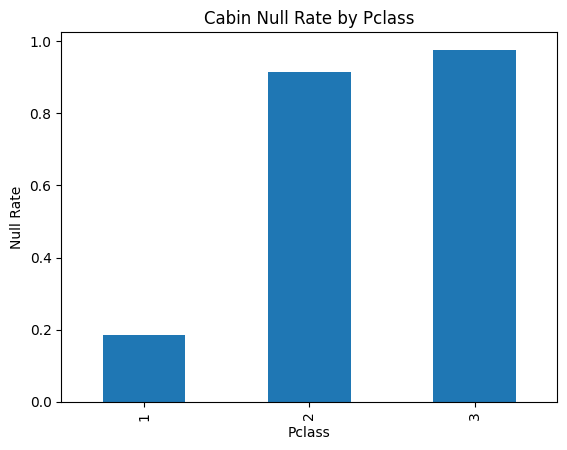

In [261]:
df.groupby('Pclass')['Cabin_null'].mean().plot(kind='bar', title='Cabin Null Rate by Pclass')
plt.ylabel('Null Rate')
plt.show()

Pclass in {2,3} most likely to have null `cabin`.
This suggest structural information in the data. Looking online, cabin is a luxury. So if say first class is pclass = 1, then it checks out why majority of pclass = 1 has a cabin value. 

As for why not everyone in pclass=1 has a cabin assignment could just be due to naturally missing data.

### Result
We should flag cabin NaN.
- Significance of NaN is signal in itself -> should not drop signal
- Cabin values are not continuous -> cannot do imputation


In [262]:
df['has_cabin'] = df['Cabin'].notna().astype(int)

print(df.groupby('has_cabin')['Survived'].agg(['count', 'mean'])
        .rename(index={0: 'No Cabin', 1: 'Has Cabin'}, columns={'mean': 'survival_rate'}))
print(f"\nhas_cabin value counts:\n{df['has_cabin'].value_counts().to_string()}")

           count  survival_rate
has_cabin                      
No Cabin     687       0.299854
Has Cabin    204       0.666667

has_cabin value counts:
has_cabin
0    687
1    204


## 2. Embarked

Lets rerun our code block from before...

In [263]:
# Survival rate by present vs null for each column
print(f"{'Column':<15} {'Present':>10} {'Null':>10} {'Δ':>8}")
print("─" * 45)
for col in df.columns:
    if col == 'Survived':
        continue
    has = df[col].notna()
    n_present = has.sum()
    n_null = (~has).sum()
    if n_null == 0:
        continue
    rate_present = df.loc[has, 'Survived'].mean()
    rate_null = df.loc[~has, 'Survived'].mean()
    delta = rate_present - rate_null
    print(f"{col:<15} {rate_present:>9.1%} {rate_null:>9.1%} {delta:>+7.1%}")
    print(f"{'':15} (n={n_present:<4})    (n={n_null:<4})")

Column             Present       Null        Δ
─────────────────────────────────────────────
Age                 40.6%     29.4%  +11.2%
                (n=714 )    (n=177 )
Cabin               66.7%     30.0%  +36.7%
                (n=204 )    (n=687 )
Embarked            38.2%    100.0%  -61.8%
                (n=889 )    (n=2   )


Without looking too deeply into the data, we can see that:
Count(isNaN(Embarked)) = 2

Given 2 data points accounts for much less than 1% of the data, we can safely drop these instances.

In [264]:
df = df.dropna(subset=['Embarked'])
print(f"Dropped Embarked NaNs. Rows: {len(df)} (was 891)")

Dropped Embarked NaNs. Rows: 889 (was 891)


## Age

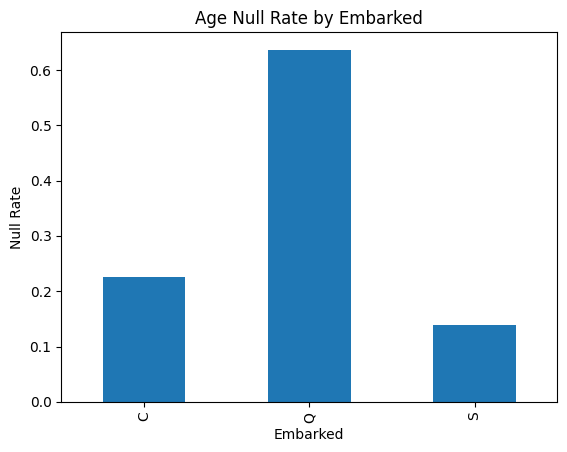

In [265]:
df.groupby('Embarked')['Age_null'].mean().plot(kind='bar', title='Age Null Rate by Embarked')
plt.ylabel('Null Rate')
plt.show()

In [266]:

# Group by Embarked: survival, class mix, fare, age
embarked_summary = df.groupby('Embarked').agg(
    count=('PassengerId', 'size'),
    survival_rate=('Survived', 'mean'),
    mean_fare=('Fare', 'mean'),
    median_fare=('Fare', 'median'),
    mean_age=('Age', 'mean'),
    pct_female=('Sex', lambda x: (x == 'female').mean()),
    age_null_rate=('Age_null', 'mean'),
).round(3)
print(embarked_summary)

print("\n── Pclass distribution per port ──")
print(pd.crosstab(df['Embarked'], df['Pclass'], normalize='index').round(3))


          count  survival_rate  mean_fare  median_fare  mean_age  pct_female  \
Embarked                                                                       
C           168          0.554     59.954        29.70    30.815       0.435   
Q            77          0.390     13.276         7.75    28.089       0.468   
S           644          0.337     27.080        13.00    29.445       0.315   

          age_null_rate  
Embarked                 
C                 0.226  
Q                 0.636  
S                 0.140  

── Pclass distribution per port ──
Pclass        1      2      3
Embarked                     
C         0.506  0.101  0.393
Q         0.026  0.039  0.935
S         0.197  0.255  0.548


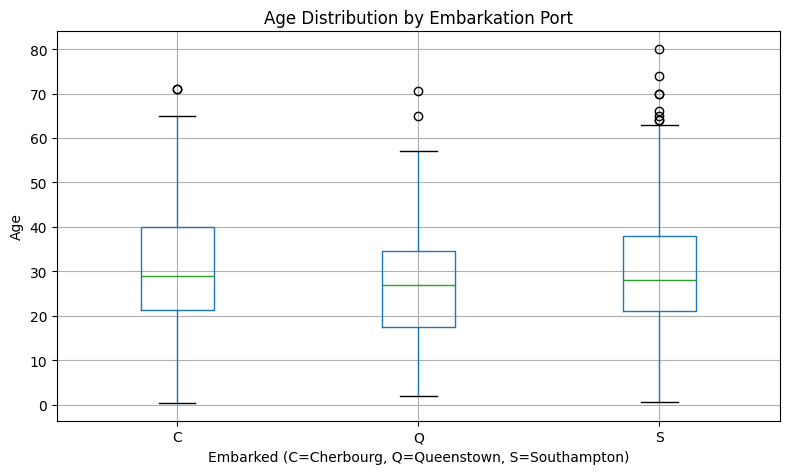

In [267]:

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='Age', by='Embarked', ax=ax)
ax.set_title('Age Distribution by Embarkation Port')
ax.set_xlabel('Embarked (C=Cherbourg, Q=Queenstown, S=Southampton)')
ax.set_ylabel('Age')
plt.suptitle('')
plt.tight_layout()
plt.show()


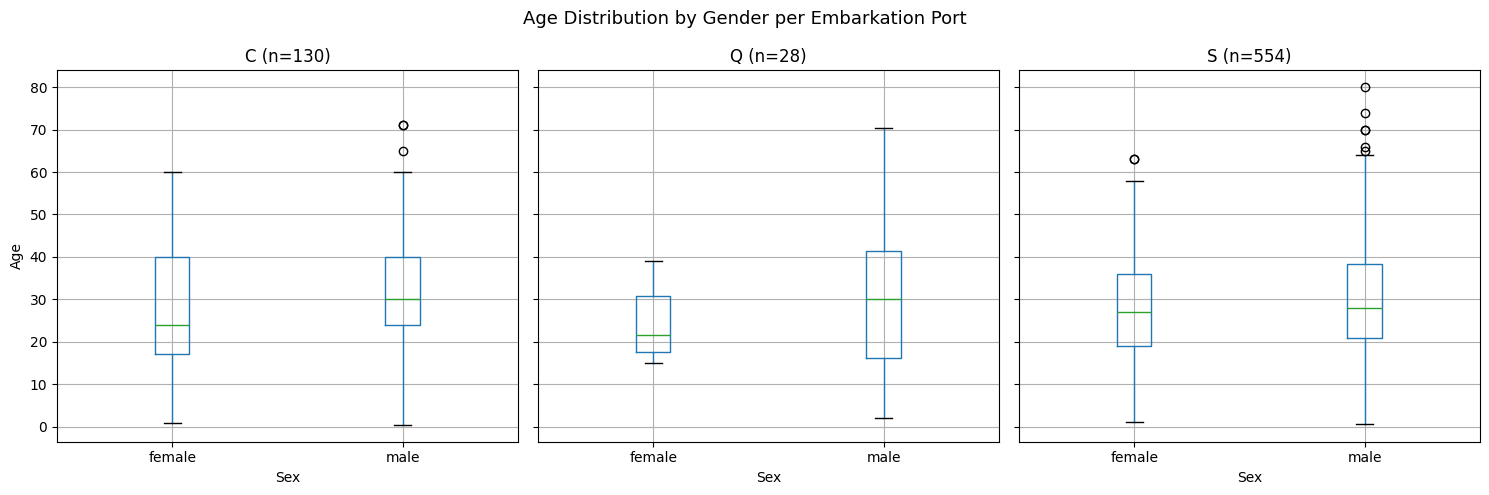

In [268]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, port in zip(axes, ['C', 'Q', 'S']):
    port_data = df[df['Embarked'] == port].dropna(subset=['Age'])
    port_data.boxplot(column='Age', by='Sex', ax=ax)
    ax.set_title(f'{port} (n={len(port_data)})')
    ax.set_xlabel('Sex')
    if ax == axes[0]:
        ax.set_ylabel('Age')
    else:
        ax.set_ylabel('')

plt.suptitle('Age Distribution by Gender per Embarkation Port', fontsize=13)
plt.tight_layout()
plt.show()


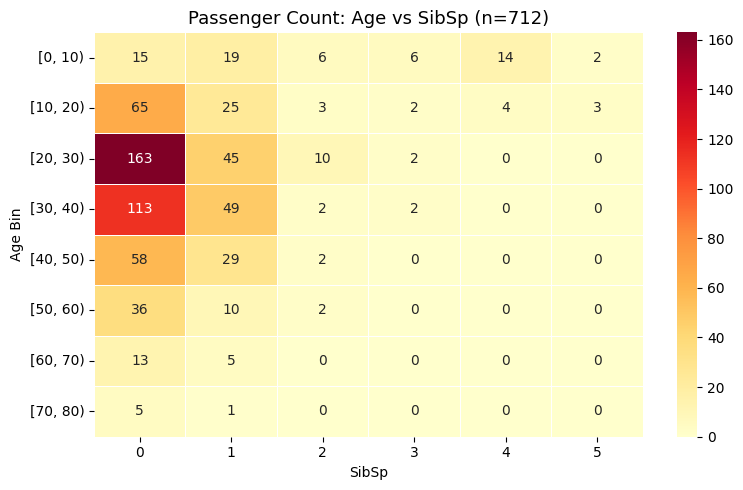

In [269]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]

fig, ax = plt.subplots(figsize=(8, 5))

data = df.dropna(subset=['Age']).copy()
data['AgeBin'] = pd.cut(data['Age'], bins=age_bins, right=False)

ct = pd.crosstab(data['AgeBin'], data['SibSp'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title(f'Passenger Count: Age vs SibSp (n={len(data)})', fontsize=13)
ax.set_xlabel('SibSp')
ax.set_ylabel('Age Bin')

plt.tight_layout()
plt.show()

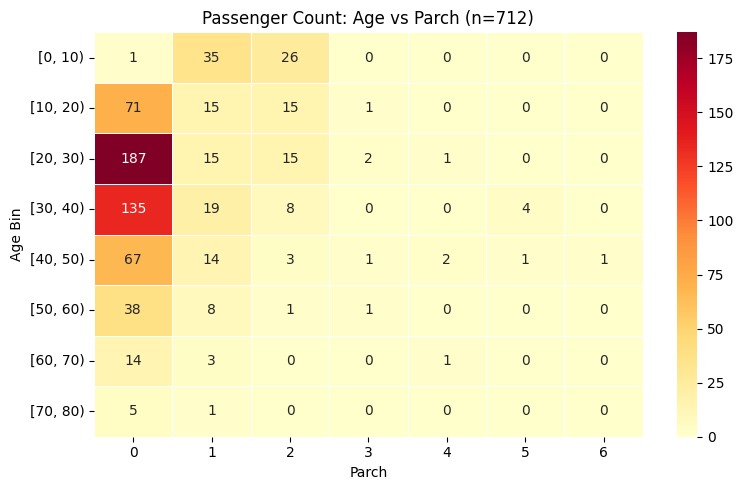

In [270]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]

data = df.dropna(subset=['Age']).copy()
data['AgeBin'] = pd.cut(data['Age'], bins=age_bins, right=False)

ct = pd.crosstab(data['AgeBin'], data['Parch'])

plt.figure(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title(f'Passenger Count: Age vs Parch (n={len(data)})')
plt.xlabel('Parch')
plt.ylabel('Age Bin')
plt.tight_layout()
plt.show()

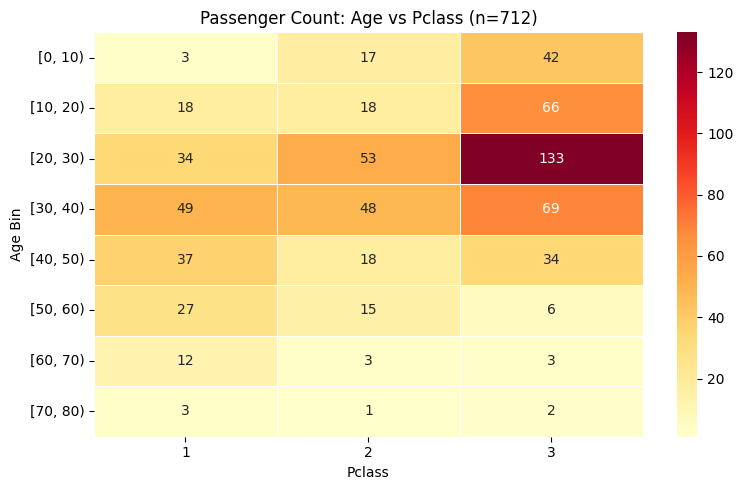

In [271]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]

data = df.dropna(subset=['Age']).copy()
data['AgeBin'] = pd.cut(data['Age'], bins=age_bins, right=False)

ct = pd.crosstab(data['AgeBin'], data['Pclass'])

plt.figure(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title(f'Passenger Count: Age vs Pclass (n={len(data)})')
plt.xlabel('Pclass')
plt.ylabel('Age Bin')
plt.tight_layout()
plt.show()

In [272]:
for col in ['Pclass', 'Sex', 'Title', 'Embarked']:
    print(df.groupby(col)['Age'].agg(['mean', 'median', 'std', 'count']))

             mean  median        std  count
Pclass                                     
1       38.105543    37.0  14.778904    184
2       29.877630    29.0  14.001077    173
3       25.140620    24.0  12.495398    355
             mean  median        std  count
Sex                                        
female  27.745174    27.0  13.989760    259
male    30.726645    29.0  14.678201    453
                   mean  median        std  count
Title                                            
Capt          70.000000    70.0        NaN      1
Col           58.000000    58.0   2.828427      2
Don           40.000000    40.0        NaN      1
Dr            42.000000    46.5  12.016655      6
Jonkheer      38.000000    38.0        NaN      1
Lady          48.000000    48.0        NaN      1
Major         48.500000    48.5   4.949747      2
Master         4.574167     3.5   3.619872     36
Miss          21.662069    21.0  12.964513    145
Mlle          24.000000    24.0   0.000000      2
Mme 

In [273]:
train = df[df['Age'].notna()]
for col in ['SibSp', 'Parch', 'Fare', 'Pclass']:
    print(f"{col}: {train[col].corr(train['Age']):.3f}")

SibSp: -0.307
Parch: -0.188
Fare: 0.093
Pclass: -0.366


Thoughts so far...
We can do linear regression to impute missing age data, using `SibSp`,`Parch`, `PClass`, as correlation with age on the data more broadly greater than `0.15`.

Logically, using these to infer age makes sense. Single travelers vs. those who travel in a family should result in the latter clustering in ages.

We can see this for `Passenger Count: Age vs Parch`, where `[0,10]` has a cluster, since most kids likely needed parents to board the titantic.

Then we see most prominent cluster of adults aged between `[20,30]` in another cluster with 0 sibSp and parch.

We see strong correlation between Age and Pclass, which makes sense since First class will likely be wealthier folks, and thus older.

### Linear Regression — Numeric Features Only
Baseline model using `SibSp`, `Parch`, `Pclass` (no title grouping).

In [274]:
from sklearn.linear_model import LinearRegression

numeric_features = ['SibSp', 'Parch', 'Pclass']
train_mask = df['Age'].notna()

X_train = df.loc[train_mask, numeric_features]
y_train = df.loc[train_mask, 'Age']

model_numeric = LinearRegression()
model_numeric.fit(X_train, y_train)

print(f"R² (numeric only) = {model_numeric.score(X_train, y_train):.3f}")
print(f"Coefficients: {dict(zip(numeric_features, model_numeric.coef_.round(3)))}")
print(f"Intercept: {model_numeric.intercept_:.3f}")

R² (numeric only) = 0.220
Coefficients: {'SibSp': np.float64(-3.94), 'Parch': np.float64(-1.403), 'Pclass': np.float64(-6.017)}
Intercept: 45.754


### Age Distribution by Title
Title within the `Name` column encodes age signal — `Master` is exclusively young boys, `Mr`/`Mrs` skew adult. Visualizing this before adding it to the regression.

In [275]:
print(df['Title'].value_counts())

Title
Mr              517
Miss            181
Mrs             124
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


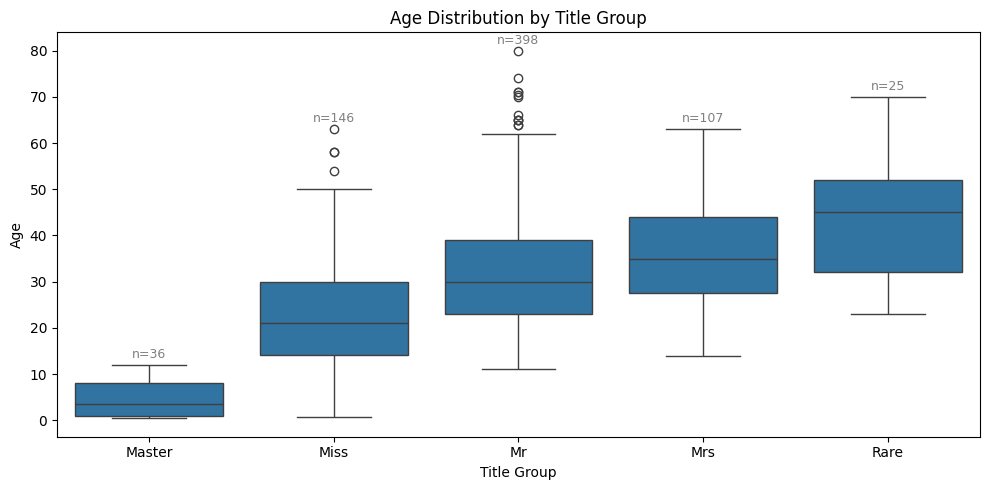

In [276]:
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master', 'Ms': 'Miss',
}
df['title_group'] = df['Title'].map(lambda t: title_map.get(t, 'Rare'))

plot_data = df.dropna(subset=['Age'])
order = plot_data.groupby('title_group')['Age'].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=plot_data, x='title_group', y='Age', order=order, ax=ax)
ax.set_title('Age Distribution by Title Group')
ax.set_xlabel('Title Group')
ax.set_ylabel('Age')

for i, title in enumerate(order):
    n = (plot_data['title_group'] == title).sum()
    ax.text(i, plot_data[plot_data['title_group'] == title]['Age'].max() + 1.5,
            f'n={n}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

In [277]:
#impute age based on title groups and pclass only
from sklearn.linear_model import LinearRegression

title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master', 'Ms': 'Miss',
}
df['title_group'] = df['Title'].map(lambda t: title_map.get(t, 'Rare'))

title_dummies = pd.get_dummies(df['title_group'], prefix='Title', drop_first=False)
title_dummies = title_dummies.drop(columns=['Title_Mr'])

X = pd.concat([df[['Pclass']], title_dummies], axis=1)

train_mask = df['Age'].notna()
X_train = X.loc[train_mask]
y_train = df.loc[train_mask, 'Age']

model_title_pclass = LinearRegression()
model_title_pclass.fit(X_train, y_train)

print(f"R² (title_group + Pclass) = {model_title_pclass.score(X_train, y_train):.3f}")
print(f"Coefficients: {dict(zip(X.columns, model_title_pclass.coef_.round(3)))}")
print(f"Intercept: {model_title_pclass.intercept_:.3f}")

print(f"\nComparison:")
print(f"  Numeric only (SibSp, Parch, Pclass):  R² = {model_numeric.score(X_train[['Pclass']], y_train) if False else 0.220}")
print(f"  Title + Pclass (this model):           R² = {model_title_pclass.score(X_train, y_train):.3f}")

R² (title_group + Pclass) = 0.386
Coefficients: {'Pclass': np.float64(-5.63), 'Title_Master': np.float64(-26.518), 'Title_Miss': np.float64(-11.707), 'Title_Mrs': np.float64(1.277), 'Title_Rare': np.float64(4.755)}
Intercept: 45.637

Comparison:
  Numeric only (SibSp, Parch, Pclass):  R² = 0.22
  Title + Pclass (this model):           R² = 0.386


The divergence in medians, quartiles, and ranges across title groups shows that title has predictive power for age — each group occupies a distinct age band, so encoding title should improve our regression.

### Linear Regression — With Title Grouping
Adding one-hot encoded `TitleGroup` and `Sex` to improve the model.

In [278]:
from sklearn.linear_model import LinearRegression

# Group rare titles for encoding
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master', 'Ms': 'Miss',
}
df['title_group'] = df['Title'].map(lambda t: title_map.get(t, 'Rare'))

# One-hot encode title_group (drop 'Mr' as baseline)
title_dummies = pd.get_dummies(df['title_group'], prefix='Title', drop_first=False)
title_dummies = title_dummies.drop(columns=['Title_Mr'])

numeric_features = ['SibSp', 'Parch', 'Pclass']
X = pd.concat([df[numeric_features], title_dummies], axis=1)

train_mask = df['Age'].notna()
X_train = X.loc[train_mask]
y_train = df.loc[train_mask, 'Age']
X_missing = X.loc[~train_mask]

model_combined = LinearRegression()
model_combined.fit(X_train, y_train)

n = len(X_train)

def adj_r2(model, X, y):
    r2 = model.score(X, y)
    p = X.shape[1]
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R² (numeric + title_group) = {model_combined.score(X_train, y_train):.3f}")
print(f"Coefficients: {dict(zip(X.columns, model_combined.coef_.round(3)))}")
print(f"Intercept: {model_combined.intercept_:.3f}")

print(f"\nComparison (R² / Adj R²):")
models = [
    ("Numeric only (SibSp, Parch, Pclass)", model_numeric, X_train[numeric_features]),
    ("Title + Pclass",                      model_title_pclass, X_train[['Pclass'] + list(title_dummies.columns)]),
    ("Combined (this model)",               model_combined, X_train),
]
for label, m, X_sub in models:
    r2 = m.score(X_sub, y_train)
    ar2 = adj_r2(m, X_sub, y_train)
    print(f"  {label:<40s} R² = {r2:.3f}   Adj R² = {ar2:.3f}   (p={X_sub.shape[1]})")

predicted = model_combined.predict(X_missing).clip(0)
df.loc[~train_mask, 'Age'] = predicted

print(f"\nImputed {(~train_mask).sum()} missing ages")
print(f"Imputed age range: {predicted.min():.1f} – {predicted.max():.1f}")
print(f"Remaining nulls: {df['Age'].isna().sum()}")

R² (numeric + title_group) = 0.400
Coefficients: {'SibSp': np.float64(-1.909), 'Parch': np.float64(-0.475), 'Pclass': np.float64(-5.496), 'Title_Master': np.float64(-22.327), 'Title_Miss': np.float64(-10.866), 'Title_Mrs': np.float64(2.512), 'Title_Rare': np.float64(4.916)}
Intercept: 45.947

Comparison (R² / Adj R²):
  Numeric only (SibSp, Parch, Pclass)      R² = 0.220   Adj R² = 0.217   (p=3)
  Title + Pclass                           R² = 0.386   Adj R² = 0.382   (p=5)
  Combined (this model)                    R² = 0.400   Adj R² = 0.394   (p=7)

Imputed 177 missing ages
Imputed age range: 0.0 – 45.4
Remaining nulls: 0


In [279]:
df = df.drop(columns=['Cabin_null', 'Embarked_null'])
print(f"Dropped redundant columns. Remaining: {list(df.columns)}")

Dropped redundant columns. Remaining: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'Age_null', 'has_cabin', 'title_group']


## Export Cleaned Data

In [280]:
df.to_csv('data/train_cleaned.csv', index=False)
print(f"Saved {len(df)} rows, {len(df.columns)} columns to data/train_cleaned.csv")
print(f"Columns: {list(df.columns)}")

Saved 889 rows, 16 columns to data/train_cleaned.csv
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'Age_null', 'has_cabin', 'title_group']
